## Loading

In [ ]:
import spikeinterface as si
import RCP_analysis as rcp
from RCP_analysis.python.functions.config_loading import *

# Config
RATES = PARAMS.NPRW_rate_est
BIN_MS     = RATES.get("bin_ms")
SIGMA_MS   = RATES.get("sigma_ms")
THRESH     = RATES.get("detect_threshold")
PEAK_SIGN  = RATES.get("peak_sign")

NPRW_CKPT_OUT = OUT_BASE / "checkpoints" / "NPRW"

INDEX = 1

global_job_kwargs = dict(n_jobs=PARAMS.parallel_jobs, chunk_duration=PARAMS.chunk)
si.set_global_job_kwargs(**global_job_kwargs)


# 2) Find sessions and load data from each Intan folder
sess_folders = rcp.list_intan_sessions(INTAN_ROOT)
print(f"Found Intan sessions: {len(sess_folders)}")

nprw_pp_folders = sorted(NPRW_CKPT_OUT.glob("pp_*"))
nprw_pp_folder = nprw_pp_folders[INDEX]
print(nprw_pp_folder)

nprw_peaks_folders = sorted(NPRW_CKPT_OUT.glob("rates__*.npz"))
nprw_peaks_folder = nprw_peaks_folders[INDEX]
print(nprw_peaks_folder)

# for sess in sess_folders[:]: # Can tweak here to isolate sessions
rec_nprw = si.load(nprw_pp_folder)

def _parse_SI_peaks(peaks, n_channels: int) -> tuple[dict[int, np.ndarray], dict[int, np.ndarray]]:
    peak_times: dict[int, np.ndarray] = {i: np.array([], dtype=np.int64) for i in range(n_channels)}
    peak_amp: dict[int, np.ndarray] = {i: np.array([], dtype=np.float32) for i in range(n_channels)}

    ch_idx = peaks["channel_index"]
    for i in np.unique(ch_idx):
        ii = int(i)
        if ii >= n_channels:
            continue
        m = (ch_idx == i)
        peak_times[ii] = peaks["sample_index"][m]
        peak_amp[ii] = peaks["amplitude"][m]

    return peak_times, peak_amp

nprw_peaks_si_obj = np.load(nprw_peaks_folder, allow_pickle=True)
nprw_peak_samps, nprw_peak_amps = _parse_SI_peaks(nprw_peaks_si_obj['peaks'], 128)
nprw_peak_ms   = {k: (v / 30000)   * 1000.0 for k, v in nprw_peak_samps.items()}

SESSION = nprw_peaks_si_obj['meta'].item()['session']

NPRW_SORT_CKPT_OUT = OUT_BASE / "checkpoints" / "sorting_results" / SESSION / "NPRW" / "folder_KS4"
NPRW_SORT_ANALYZE_CKPT_OUT = OUT_BASE / "checkpoints" / "sorting_results" / SESSION / "NPRW" / "my_sorting_analyzer"

Found Intan sessions: 63
/media/bryan/Expansion/Nike/20260324_NRR_RW026/results/checkpoints/NPRW/pp_local_30_150__interp_NRR_RW026_260324_122125
/media/bryan/Expansion/Nike/20260324_NRR_RW026/results/checkpoints/NPRW/rates__NRR_RW026_260324_122125__bin20ms_sigma20ms.npz


## Sorting

In [3]:
import spikeinterface.curation as scur
import spikeinterface.sorters as ss

job_kwargs = dict(n_jobs=-1, progress_bar=True, chunk_duration="1s")
sorting_KS4 = ss.run_sorter(sorter_name="kilosort4", recording=rec_nprw, folder=NPRW_SORT_CKPT_OUT, remove_existing_folder=True)

sorting_KS4 = scur.remove_duplicated_spikes(sorting_KS4)
sorting_KS4 = scur.remove_excess_spikes(sorting_KS4, rec_nprw)
sorting_KS4 = scur.remove_redundant_units(sorting_KS4, align=False, remove_strategy="max_spikes")

analyzer = si.create_sorting_analyzer(sorting_KS4, rec_nprw,
                                              format="binary_folder", folder=NPRW_SORT_ANALYZE_CKPT_OUT,
                                              overwrite=True,
                                              **job_kwargs)

analyzer.compute(
    [
        "random_spikes",
        "waveforms",
        "templates",
        "noise_levels",
        "unit_locations",
        "isi_histograms",
        "correlograms",
        "principal_components",
        "quality_metrics",
        "template_similarity",
        "spike_amplitudes",
    ],
    extension_params={
        "quality_metrics": {
            "metric_names": ["snr", "firing_rate", "rp_violation"],
            "metric_params": {"rp_violation": {"refractory_period_ms": 0.5}},
        },
    },
    **job_kwargs
)
analyzer.get_saved_extension_names()
analyzer.get_extension("quality_metrics").get_data().head()

100%|██████████| 1/1 [00:02<00:00,  2.61s/it]


estimate_sparsity (workers: 12 processes fork):   0%|          | 0/71 [00:00<?, ?it/s]

/home/bryan/miniconda3/envs/pipeline/lib/python3.10/site-packages/spikeinterface/core/basesorting.py:384: UserWarning: The registered recording will not be persistent on disk, but only available in memory
  warnings.warn("The registered recording will not be persistent on disk, but only available in memory")


compute_waveforms (workers: 12 processes fork):   0%|          | 0/71 [00:00<?, ?it/s]

noise_level (workers: 12 processes fork):   0%|          | 0/20 [00:00<?, ?it/s]

Fitting PCA:   0%|          | 0/56 [00:00<?, ?it/s]

Projecting waveforms:   0%|          | 0/56 [00:00<?, ?it/s]

/home/bryan/miniconda3/envs/pipeline/lib/python3.10/site-packages/spikeinterface/postprocessing/template_similarity.py:345: NumbaTypeSafetyWarning: unsafe cast from uint64 to int64. Precision may be lost.
  overlapping_ids = overlapping_j_list[i]


Compute : spike_amplitudes (workers: 12 processes fork):   0%|          | 0/71 [00:00<?, ?it/s]

,snr,firing_rate,rp_contamination,rp_violations
0,4.233004,5.780740,0.610105,1
1,0.698295,6.616680,1.000000,2
2,2.856468,2.536158,0.000000,0
3,1.754536,3.074560,0.000000,0
4,6.389902,6.347479,0.000000,0


In [4]:
# analyzer = si.load_sorting_analyzer(NPRW_SORT_ANALYZE_CKPT_OUT)
# analyzer.set_temporary_recording(rec_nprw)  # re-attach in memory

In [5]:
from spikeinterface.curation import compute_merge_unit_groups

merge_unit_groups = compute_merge_unit_groups(
    sorting_analyzer=analyzer,
    preset="slay",
    resolve_graph=True
)
print(merge_unit_groups)
if merge_unit_groups is not None and len(merge_unit_groups) > 0:
    # here we apply the merges
    analyzer_merged = analyzer.merge_units(merge_unit_groups=merge_unit_groups)

[]


In [6]:
def peri_event_rates_from_peaks_ms(
    peaks_ms: dict[int, np.ndarray],
    event_times_ms: np.ndarray,
    win_ms=(-600.0, 600.0),
    bin_ms=20.0,
    sigma_ms=50.0,
):
    """
    Compute peri-event firing rates from spike times (ms).

    Args
    ----
    peaks_ms:
        dict {unit_id: spike_times_ms}
    event_times_ms:
        (n_events,) array of event times in ms (same timebase as peaks_ms)
    win_ms:
        (start_ms, end_ms) peri-event window relative to each event
    bin_ms:
        bin width in ms
    sigma_ms:
        Gaussian smoothing sigma in ms (0 disables smoothing)

    Returns
    -------
    rates_hz:
        (n_events, n_units, n_bins) smoothed peri-event rates in Hz
    centers_ms:
        (n_bins,) bin centers in ms relative to event
    unit_ids:
        list of unit_ids in the same order as axis=1
    """
    event_times_ms = np.asarray(event_times_ms, dtype=float).ravel()
    if event_times_ms.size == 0:
        raise ValueError("event_times_ms is empty.")

    unit_ids = sorted(peaks_ms.keys())
    n_units = len(unit_ids)
    if n_units == 0:
        raise ValueError("peaks_ms is empty.")

    w0, w1 = float(win_ms[0]), float(win_ms[1])
    if w1 <= w0:
        raise ValueError("win_ms must satisfy win_ms[1] > win_ms[0].")

    # Uniform bins across the full window
    edges_ms = np.arange(w0, w1 + bin_ms, bin_ms, dtype=float)
    centers_ms = edges_ms[:-1] + 0.5 * bin_ms
    n_bins = centers_ms.size

    # Allocate output
    rates = np.zeros((event_times_ms.size, n_units, n_bins), dtype=float)

    # Bin per event, per unit
    bin_s = bin_ms / 1000.0
    for ei, t0 in enumerate(event_times_ms):
        for ui, u in enumerate(unit_ids):
            st = np.asarray(peaks_ms[u], dtype=float)
            if st.size == 0:
                continue

            rel = st - t0  # ms relative to event
            # keep only spikes in window (saves time)
            rel = rel[(rel >= w0) & (rel < w1)]
            if rel.size == 0:
                continue

            counts, _ = np.histogram(rel, bins=edges_ms)
            rates[ei, ui] = counts / bin_s  # Hz

    # Gaussian smoothing along time axis (per event, per unit)
    if sigma_ms is not None and sigma_ms > 0:
        sigma_bins = sigma_ms / bin_ms
        r = int(np.ceil(4 * sigma_bins))
        k = np.arange(-r, r + 1, dtype=float)
        g = np.exp(-(k**2) / (2.0 * sigma_bins**2))
        g /= g.sum()

        # convolve along last axis
        # (simple and reliable; fast enough for typical n_events x n_units)
        sm = np.empty_like(rates)
        for ei in range(rates.shape[0]):
            for ui in range(rates.shape[1]):
                sm[ei, ui] = np.convolve(rates[ei, ui], g, mode="same")
        rates = sm

    return rates, centers_ms, unit_ids, edges_ms

## Plot Sorted Spikes, looks good on INDEX = 1 because no big artifacts, looks bad on INDEX = 22 because big artifacts

In [7]:
# analyzer = si.load_sorting_analyzer(NPRW_SORT_ANALYZE_CKPT_OUT)
# analyzer.set_temporary_recording(rec_nprw)  # re-attach in memory

In [8]:
# FR estimate params
BIN_MS = 20.0
SIGMA_MS = 20.0

def peaks_ms_from_sorting(sorting, fs, segment_index=0):
    peaks_ms = {}
    for u in sorting.get_unit_ids():
        st_samp = sorting.get_unit_spike_train(u, segment_index=segment_index)
        peaks_ms[int(u)] = (st_samp.astype(np.float64) / fs) * 1000.0
    return peaks_ms

sorting = analyzer.sorting
rec = analyzer.recording
fs = rec.get_sampling_frequency()

peaks_ms = peaks_ms_from_sorting(sorting, fs, segment_index=0)

ir_ms = np.asarray(nprw_peaks_si_obj["ir_ms"], float).ravel()
rates_hz, centers_ms, unit_ids, edges_ms = peri_event_rates_from_peaks_ms(
    peaks_ms=peaks_ms,
    event_times_ms=ir_ms,
    win_ms=(-600, 600),
    bin_ms=BIN_MS,
    sigma_ms=SIGMA_MS,
)

psth_hz = np.nanmean(rates_hz, axis=0)   # (n_units, n_bins)

# z score per unit
mu  = np.nanmean(rates_hz[:, :, :], axis=2, keepdims=True)
sig = np.nanstd (rates_hz[:, :, :], axis=2, keepdims=True)
sig = np.clip(sig, 1e-6, None)
rates_z = (rates_hz - mu) / sig
psth_z = np.nanmean(rates_z, axis=0)

peak_mask = (centers_ms >= -600) & (centers_ms <= 600)

X = psth_z[:, peak_mask]
t = centers_ms[peak_mask]

# Peak value and peak time (argmax) within the search window
X_finite = np.where(np.isfinite(X), X, -np.inf)
peak_idx = np.argmax(X_finite, axis=1)
peak_time_ms = t[peak_idx]
peak_val = np.max(X_finite, axis=1)

# Keep only neurons with a real response; rest go to bottom
z_thresh = 0.1  # tune (0.5–1.5 is common)
responsive = np.isfinite(peak_val) & (peak_val >= z_thresh)

order_resp = np.argsort(peak_time_ms[responsive])  # earliest first
order = np.concatenate([np.where(responsive)[0][order_resp],
                        np.where(~responsive)[0]])

psth_sorted = psth_z[order]

In [9]:
print("rates_hz:", rates_hz.shape)  # (n_events, n_units, n_bins)
print("psth_hz:", psth_hz.shape)    # (n_units, n_bins)
print("time window:", centers_ms[0], "to", centers_ms[-1], "ms")

rates_hz: (11, 56, 60)
psth_hz: (56, 60)
time window: -590.0 to 590.0 ms


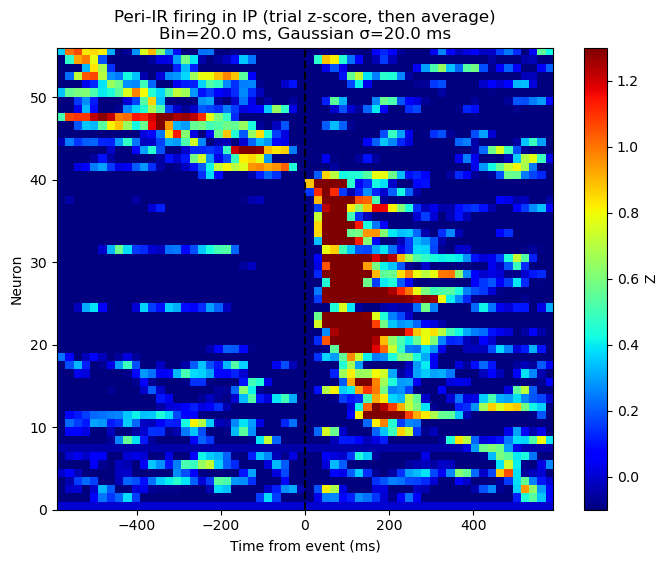

In [ ]:
%matplotlib inline

plt.figure(figsize=(8,6))
plt.imshow(
    psth_sorted,
    aspect="auto",
    origin="upper",
    extent=[centers_ms[0], centers_ms[-1], 0, psth_z.shape[0]],
    cmap="jet",
    vmin=-0.1,
    vmax=1.3,
)
plt.axvline(0, linestyle="--", color="black")
plt.xlabel("Time from event (ms)")
plt.ylabel("Neuron")
plt.title(
    f"Peri-IR firing in IP (trial z-score, then average)\nBin={BIN_MS} ms, Gaussian σ={SIGMA_MS} ms"
)
plt.colorbar(label="Z")
plt.show()

## Templates in stim trials

In [11]:
# analyzer = si.load_sorting_analyzer(NPRW_SORT_ANALYZE_CKPT_OUT)
# analyzer.set_temporary_recording(rec_nprw)  # re-attach in memory

In [12]:
sorting = analyzer.sorting
rec_nprw = analyzer.recording
fs = rec_nprw.get_sampling_frequency() 
templates = analyzer.load_extension(extension_name="templates")

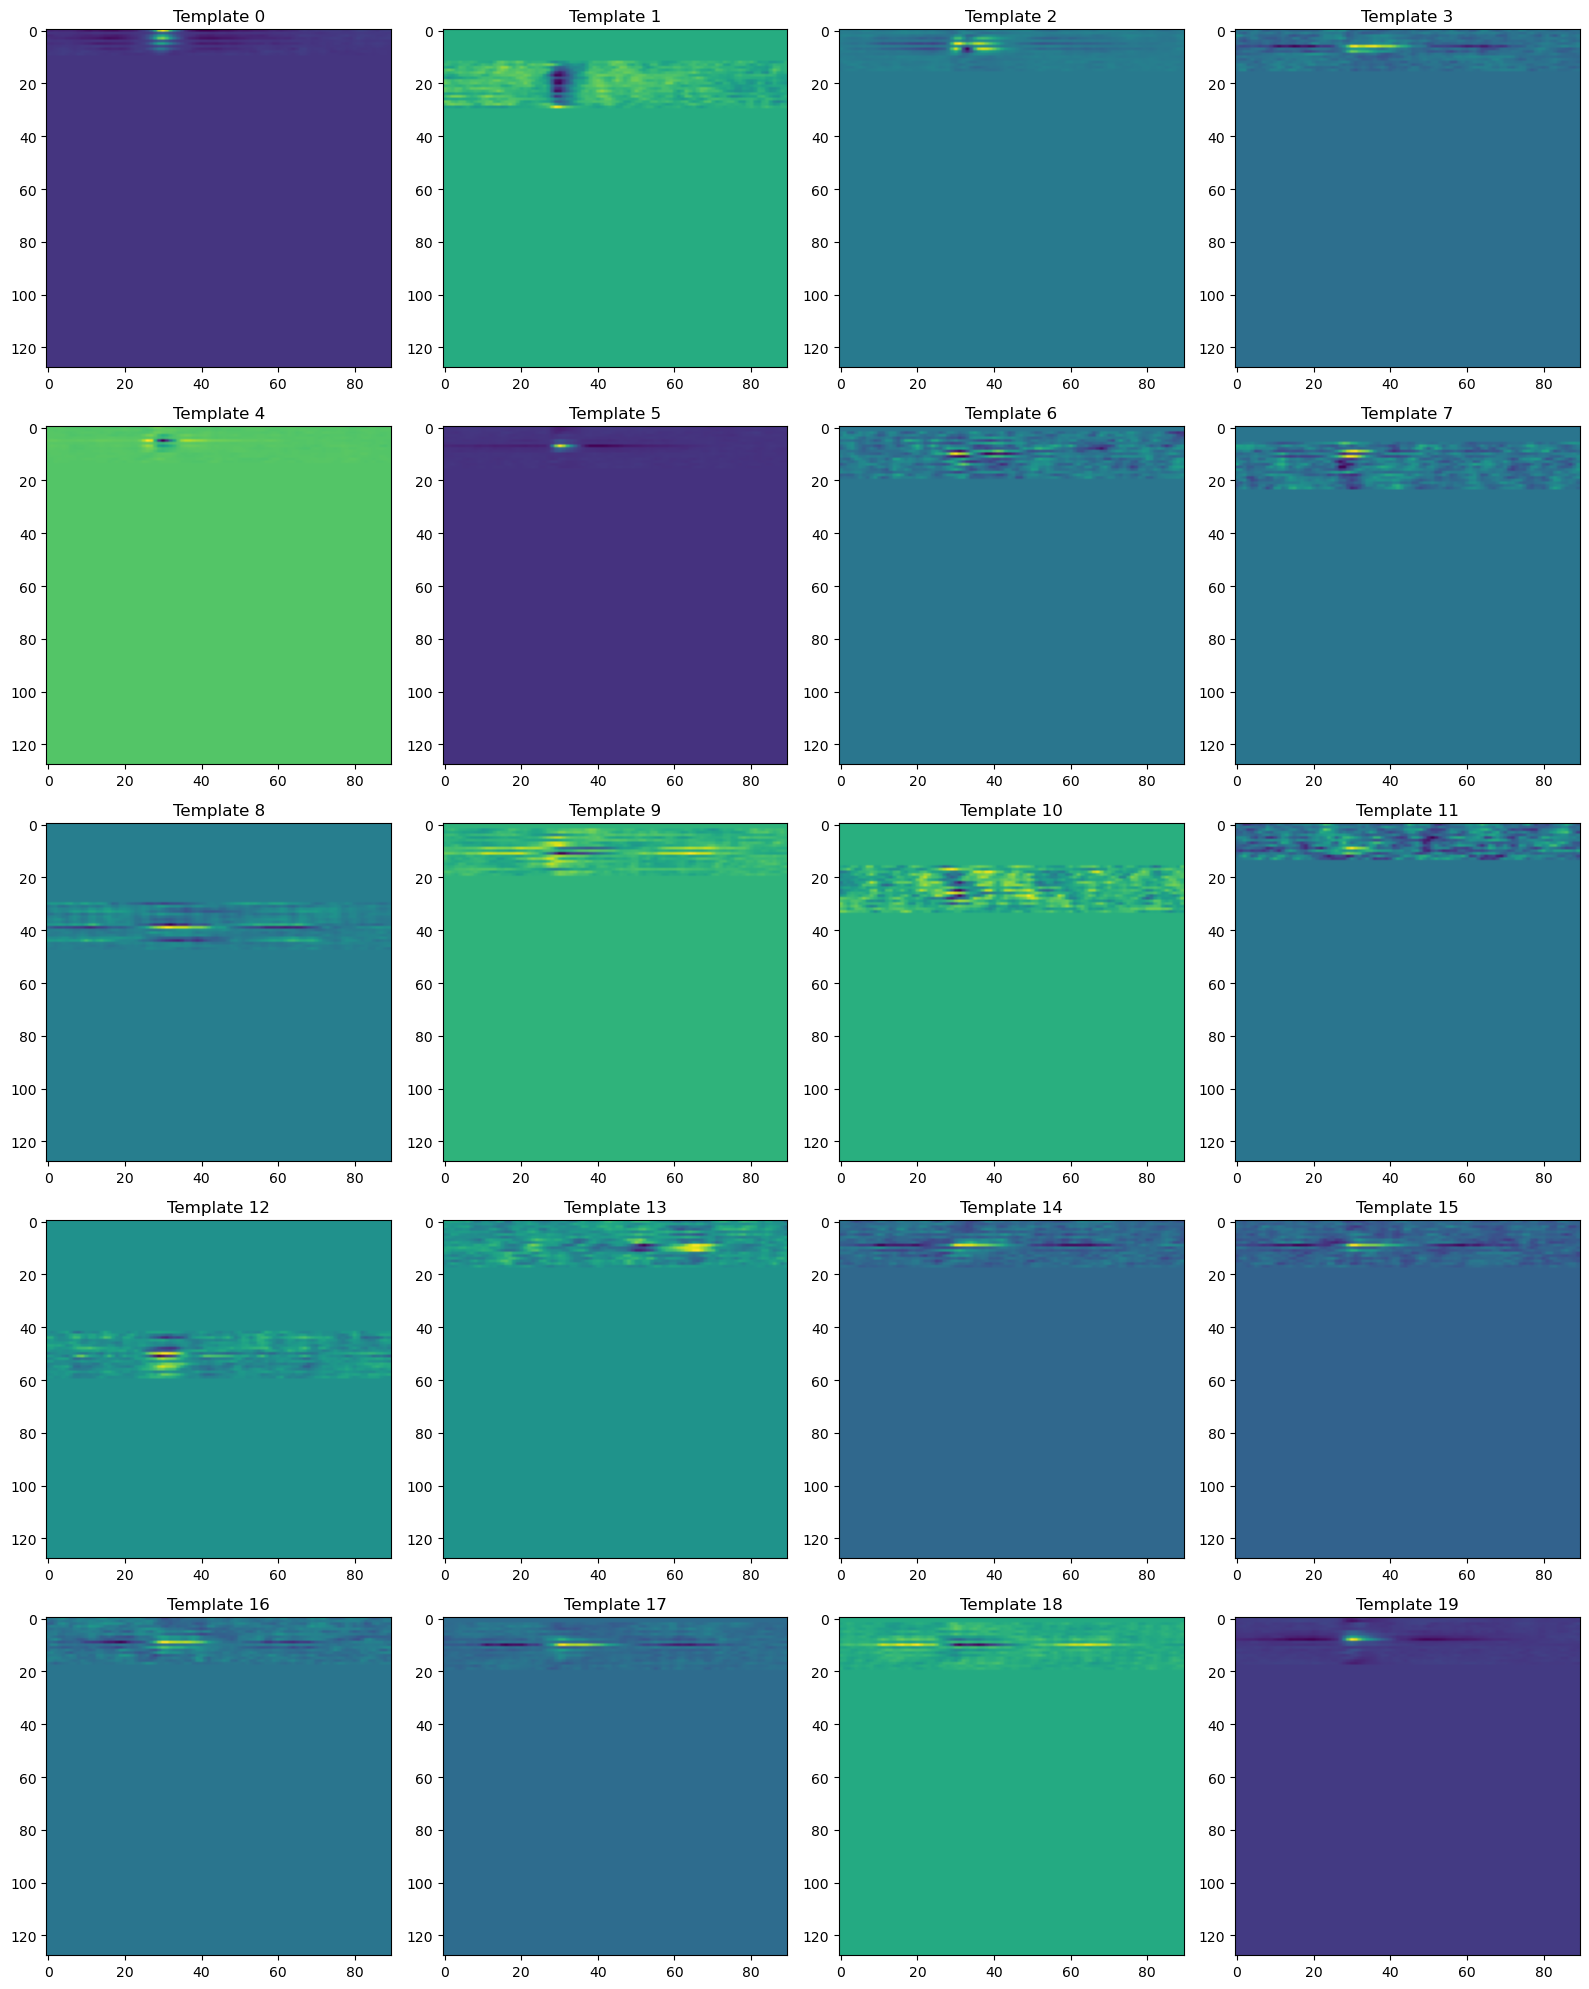

In [13]:
# Plot templates
fig, axes = plt.subplots(5, 4, figsize=(16, 20))

for i in range(20):
    axes[i//4, i%4].imshow(templates.data['average'][i, :, :].T, aspect='auto')
    axes[i//4, i%4].set_title(f'Template {i}')

plt.tight_layout()
plt.show()

In [14]:
extremum_channel_map = si.get_template_extremum_channel(analyzer)
unit_ids = analyzer.unit_ids

extremum_templates = []
for i, unit_id in enumerate(unit_ids):
    ch_id = extremum_channel_map[unit_id]
    ch_idx = rec_nprw.ids_to_indices(ids=[ch_id])[0]
    extremum_templates.append(templates.data['average'][i, :, ch_idx])

extremum_templates = np.stack(extremum_templates)  # shape: (46, 90)
extremum_templates_norm = extremum_templates / np.abs(extremum_templates).max(axis=1, keepdims=True)
median_extremum_templates_norm = np.median(extremum_templates_norm, axis=0)
nbefore = np.argmin(median_extremum_templates_norm)
nafter = len(median_extremum_templates_norm) - nbefore
ms_before = nbefore/fs*1000
ms_after = nafter/fs*1000

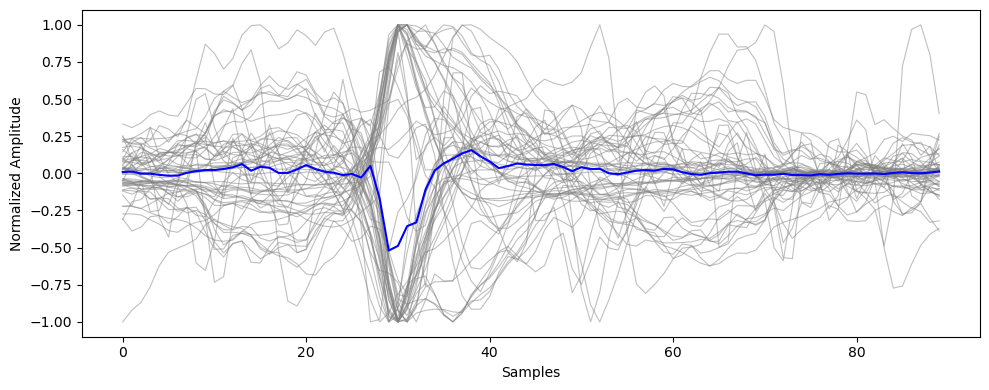

In [15]:
# Plot extremum templates
fig, ax = plt.subplots(figsize=(10, 4))

for i in range(len(extremum_templates_norm)):
    ax.plot(extremum_templates_norm[i], color='grey', alpha=0.5, linewidth=0.8)

ax.plot(median_extremum_templates_norm, color='blue', linewidth=1.5)

ax.set_xlabel("Samples")
ax.set_ylabel("Normalized Amplitude")
plt.tight_layout()
plt.show()

## Plot threshold spikes

In [16]:
THRESH = 4

from spikeinterface.sortingcomponents.peak_detection import detect_peaks
noise_levels = si.get_noise_levels(rec_nprw, method="mad", return_in_uV=False) # They didn't write return_in_uV in their documentation

nprw_peaks = detect_peaks(
    rec_nprw,
    method="by_channel_torch",
    detect_threshold=THRESH,
    peak_sign=PEAK_SIGN,
    noise_levels=noise_levels,
    n_jobs=1,
)

nprw_peak_samps, nprw_peak_amps = _parse_SI_peaks(nprw_peaks, 128)
nprw_peak_ms   = {k: (v / 30000)   * 1000.0 for k, v in nprw_peak_samps.items()}

noise_level (workers: 12 processes fork):   0%|          | 0/20 [00:00<?, ?it/s]

/home/bryan/miniconda3/envs/pipeline/lib/python3.10/site-packages/spikeinterface/sortingcomponents/peak_detection/main.py:60: UserWarning: The signature of detect_peaks() has changed, now method_kwargs and job_kwargs are dinstinct params.This warning will raise an error in version 0.105.0
  warnings.warn(


detect peaks (by_channel_torch) (no parallelization):   0%|          | 0/18 [00:00<?, ?it/s]

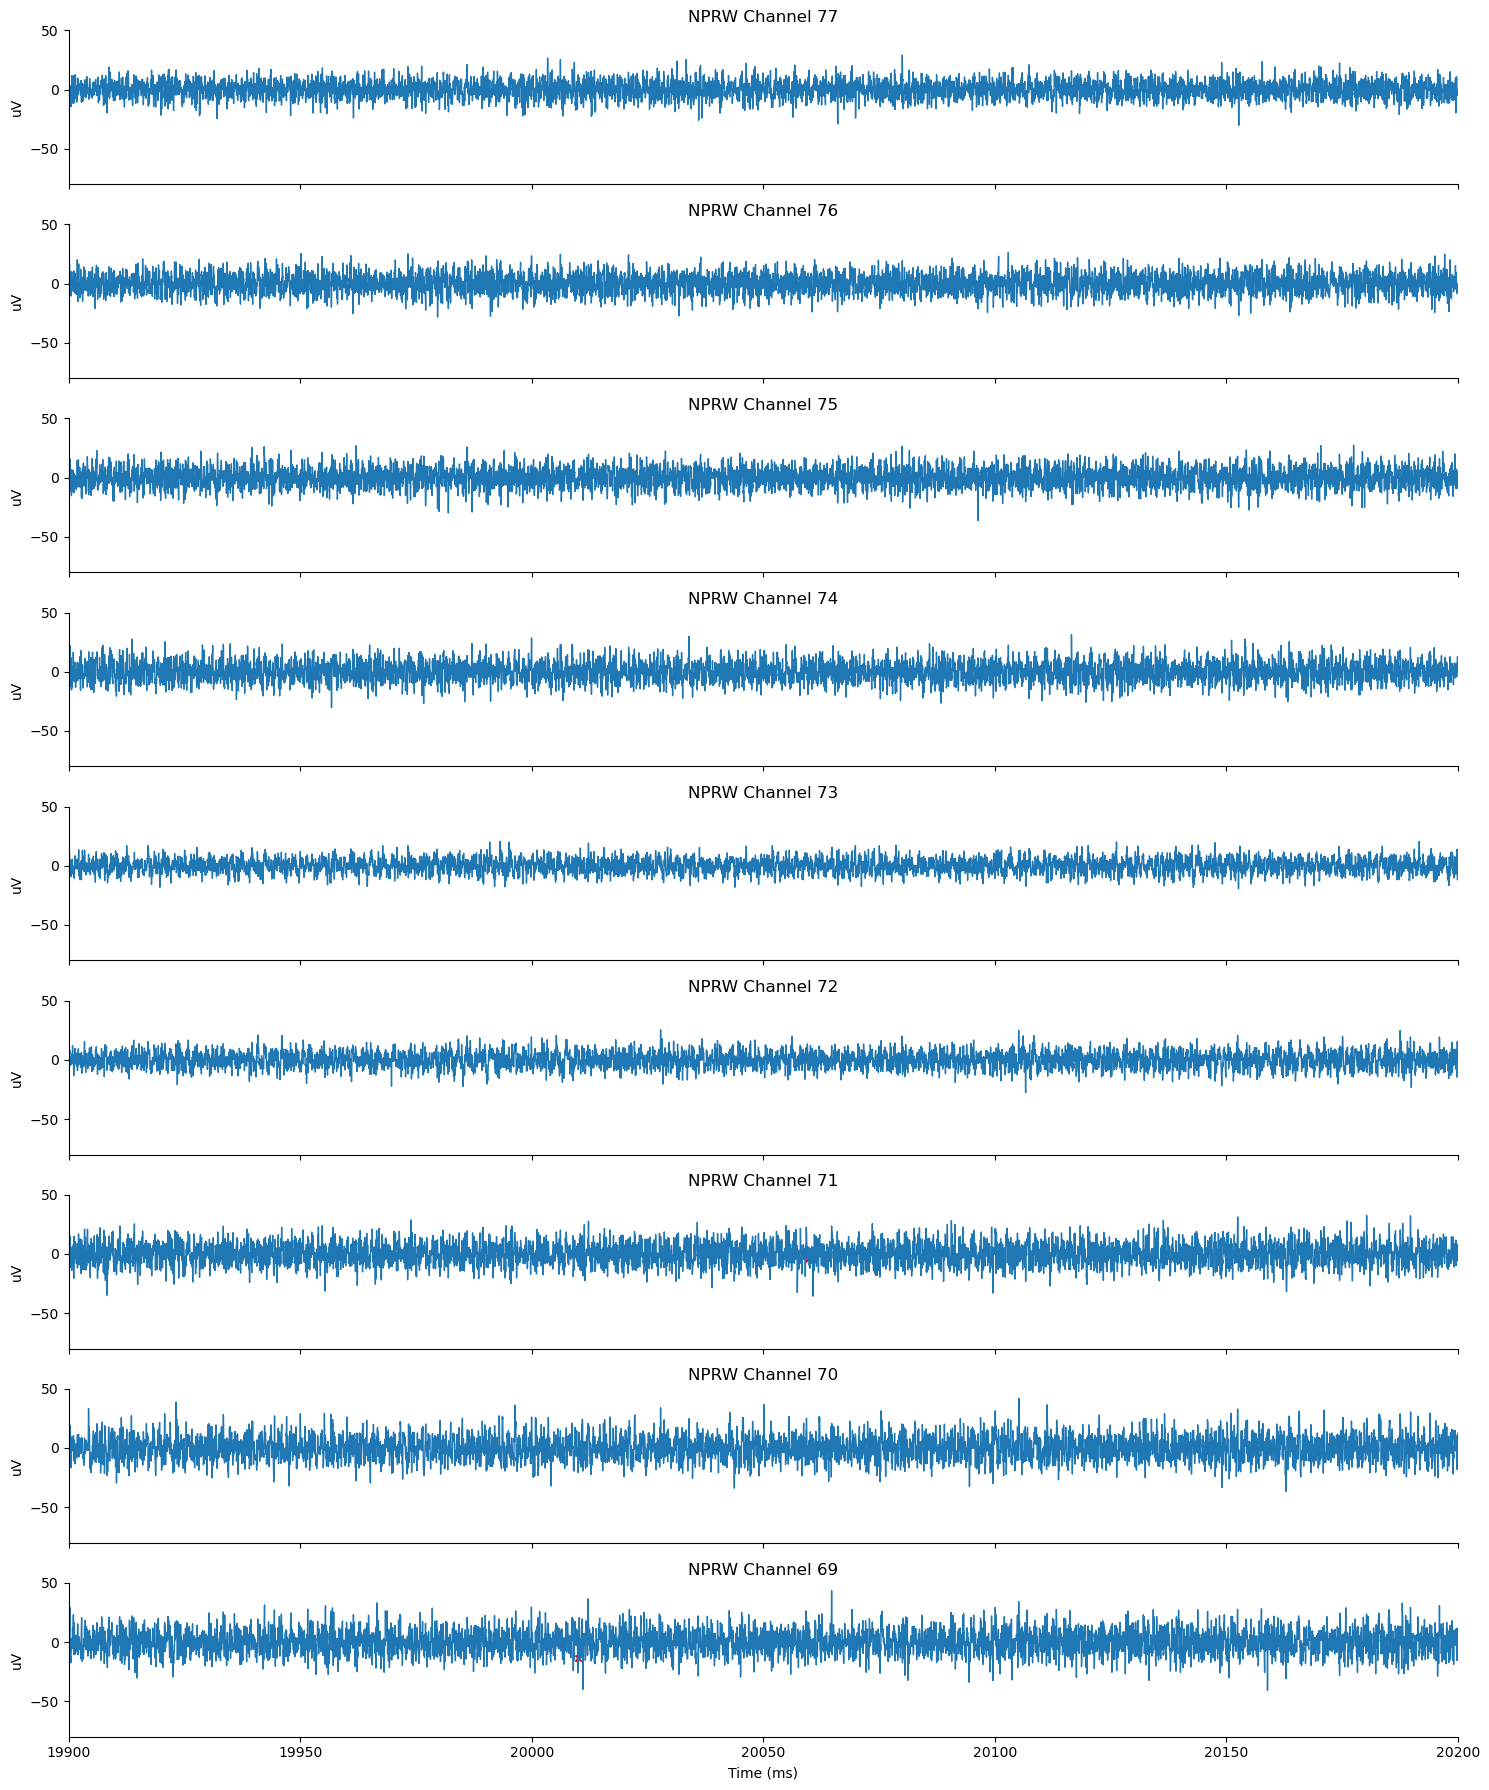

In [17]:
import numpy as np

channels = [68, 69, 70, 71, 72, 73, 74, 75, 76] # [40, 50, 60, 93] #[9, 10, 11, 31, 32, 33]

T0_MS = 19900 # 3948, 8754, 12998, 18264, 22590, 45460, 50684, 55660, 60708, 65530, 70176, 76038
T1_MS = T0_MS + 300
PLOT_SHIFT = 0

fs = fs_nprw = float(rec_nprw.get_sampling_frequency())

i0 = int(T0_MS * fs / 1000.0)
i1 = int(T1_MS * fs / 1000.0)

fig, axes = plt.subplots(len(channels), 1, figsize=(15, 3*len(channels)/1.5), sharex=True)

if len(channels) == 1:
    axes = [axes]

for ax, CH in zip(axes, channels[::-1]):

    ch_id = rec_nprw.get_channel_ids()[CH]

    # Raw trace
    y = rec_nprw.get_traces(
        start_frame=i0,
        end_frame=i1,
        channel_ids=[ch_id],
        return_in_uV=True
    ).squeeze()

    t = (np.arange(i0, i1) / fs) * 1000.0

    # Peak samples
    pk_s = np.asarray(
        nprw_peak_samps.get(CH, nprw_peak_samps.get(np.int64(CH), [])),
        dtype=np.int64
    )

    # Keep peaks inside window
    m = (pk_s >= i0) & (pk_s < i1)
    pk_s_w = pk_s[m]

    # Convert to window-relative indices
    pk_idx = (pk_s_w - i0).astype(int)

    # Convert to ms
    pk_ms_w = (pk_s_w / fs) * 1000.0

    # Sample amplitude directly from raw trace
    pk_y = y[pk_idx + PLOT_SHIFT]

    # Plot
    ax.plot(t, y, lw=1)

    if pk_ms_w.size:
        ax.scatter(
            pk_ms_w+PLOT_SHIFT/30,
            pk_y,
            s=20,
            marker="x",
            color="red"
        )

    ax.set_xlim(T0_MS, T1_MS)
    ax.set_ylim(-80, 50)
    ax.set_ylabel("uV")
    ax.set_title(f"NPRW Channel {CH+1}")
    ax.spines[["right", "top"]].set_visible(False)

axes[-1].set_xlabel("Time (ms)")
plt.tight_layout()
plt.show()